In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings("ignore")

%matplotlib inline

In [124]:
from sklearn.datasets import make_blobs

In [125]:
X, y = make_blobs(n_samples=1000, centers=3, n_features=2)

In [126]:
X

array([[ 6.37469871,  9.24105018],
       [ 7.05182929, -8.72952756],
       [ 5.71772237,  1.23302809],
       ...,
       [ 4.65360998,  1.62094615],
       [ 4.96694263,  0.73965677],
       [ 9.07931693, -9.47977742]])

In [127]:
y

array([0, 1, 2, 2, 0, 1, 0, 2, 1, 1, 2, 0, 1, 0, 1, 2, 1, 2, 0, 0, 2, 2,
       1, 1, 1, 0, 1, 0, 0, 0, 2, 1, 2, 0, 1, 2, 1, 1, 2, 0, 2, 0, 2, 1,
       2, 2, 2, 1, 2, 1, 0, 2, 0, 2, 2, 0, 1, 1, 1, 2, 0, 2, 2, 1, 0, 0,
       0, 2, 0, 0, 0, 2, 1, 1, 0, 1, 0, 1, 0, 2, 0, 0, 0, 1, 1, 0, 0, 1,
       2, 2, 1, 2, 1, 2, 2, 2, 1, 2, 0, 1, 1, 0, 2, 2, 0, 2, 0, 0, 0, 2,
       0, 0, 1, 0, 0, 0, 2, 1, 0, 2, 1, 0, 2, 0, 2, 0, 2, 1, 2, 2, 2, 1,
       2, 2, 2, 2, 1, 2, 2, 1, 2, 1, 0, 1, 2, 0, 0, 1, 0, 2, 0, 0, 1, 2,
       2, 1, 1, 0, 2, 0, 1, 0, 1, 1, 2, 2, 2, 0, 2, 2, 1, 1, 2, 2, 1, 0,
       1, 2, 1, 1, 1, 0, 0, 2, 2, 2, 0, 2, 2, 1, 0, 2, 0, 1, 0, 1, 1, 1,
       1, 2, 0, 1, 0, 2, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 2, 2, 2,
       0, 1, 0, 0, 1, 1, 2, 2, 0, 1, 2, 1, 0, 2, 0, 2, 1, 1, 1, 0, 0, 1,
       2, 2, 2, 0, 2, 1, 1, 1, 1, 0, 0, 2, 2, 1, 2, 1, 2, 2, 2, 0, 2, 2,
       1, 1, 0, 2, 0, 2, 2, 1, 1, 1, 1, 2, 1, 1, 2, 1, 0, 2, 2, 2, 0, 0,
       0, 0, 0, 0, 2, 2, 2, 2, 2, 1, 0, 2, 1, 0, 2,

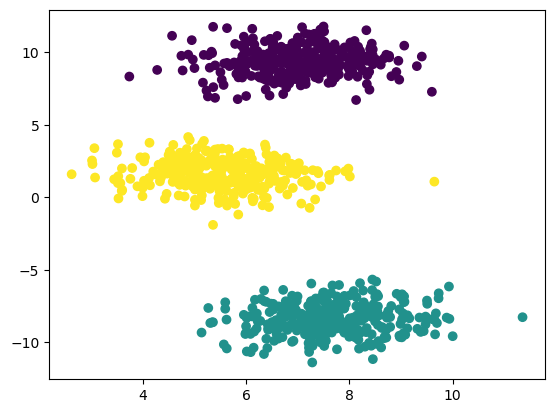

In [128]:
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

In [129]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [130]:
# standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [131]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [132]:
from sklearn.cluster import KMeans

In [133]:
# elbow method to select k value
wcss =[]
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

In [134]:
wcss

[1339.999999999999,
 634.9132215255698,
 334.9703976572742,
 255.35399646263213,
 198.9387254671436,
 144.72788536381302,
 165.62624022415653,
 105.08127584410055,
 81.4552206548627,
 72.59788798203412]

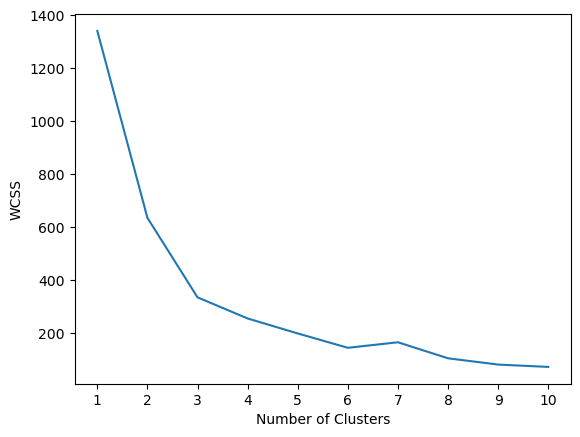

In [135]:
# plot elbow curve
plt.plot(range(1,11), wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [136]:
kmeans = KMeans(n_clusters=3, init="k-means++")

In [137]:
kmeans.fit_predict(X_train)

array([1, 2, 1, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 0, 0, 1, 2, 0, 1, 2, 0, 1,
       0, 0, 2, 1, 2, 2, 0, 2, 0, 0, 2, 1, 2, 0, 0, 1, 1, 0, 2, 2, 2, 2,
       0, 0, 1, 1, 1, 2, 2, 0, 2, 0, 0, 0, 0, 2, 2, 0, 2, 0, 2, 0, 2, 1,
       1, 0, 1, 2, 1, 0, 0, 2, 1, 1, 2, 0, 2, 1, 2, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 2, 0, 1, 2, 1, 1, 0, 0, 1, 2, 2, 1, 0, 1, 2, 2,
       0, 2, 2, 2, 1, 0, 0, 1, 1, 2, 0, 2, 2, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 2, 0, 0, 0, 0, 2, 1, 1, 1, 1, 2, 0, 1, 1, 0, 0, 1, 0, 2, 0, 2,
       0, 1, 2, 0, 0, 1, 0, 2, 0, 2, 0, 1, 2, 1, 0, 0, 1, 2, 0, 0, 2, 1,
       1, 2, 2, 0, 1, 1, 1, 2, 2, 1, 0, 1, 2, 1, 2, 2, 1, 2, 0, 1, 1, 2,
       2, 2, 0, 0, 0, 2, 1, 2, 2, 1, 2, 0, 2, 1, 1, 2, 1, 1, 1, 1, 1, 2,
       2, 2, 2, 2, 1, 1, 2, 0, 2, 0, 1, 1, 2, 1, 2, 2, 0, 2, 0, 0, 0, 2,
       2, 0, 0, 1, 0, 2, 2, 0, 1, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0,
       2, 2, 0, 2, 0, 0, 2, 1, 1, 1, 1, 0, 0, 0, 1, 2, 1, 1, 2, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 1, 1, 1, 2, 2, 2, 2, 2, 0,

In [138]:
y_pred = kmeans.predict(X_test)

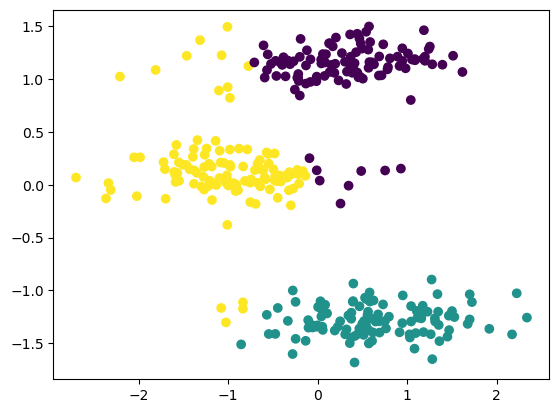

In [139]:
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred)
plt.show()

##### validation of k value
    kneelocator 
    silhoutee scoring


In [140]:
# kneelocator
!pip install kneed

In [141]:
from kneed import KneeLocator
kl = KneeLocator(range(1,11), wcss, curve='convex', direction='decreasing')

In [142]:
kl.elbow

np.int64(3)

In [ ]:
# silhouette scoring
from sklearn.metrics import silhouette_score

In [144]:
silhouette_coeff = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(X_train)
    score = silhouette_score(X_train, kmeans.labels_)
    silhouette_coeff.append(score)

In [145]:
silhouette_coeff

[np.float64(0.5200856956034291),
 np.float64(0.5373465930865318),
 np.float64(0.5024390926582881),
 np.float64(0.48652512499157635),
 np.float64(0.47523476997019165),
 np.float64(0.4710419778537954),
 np.float64(0.4707532880812737),
 np.float64(0.4630881192072922),
 np.float64(0.46780330647004814)]

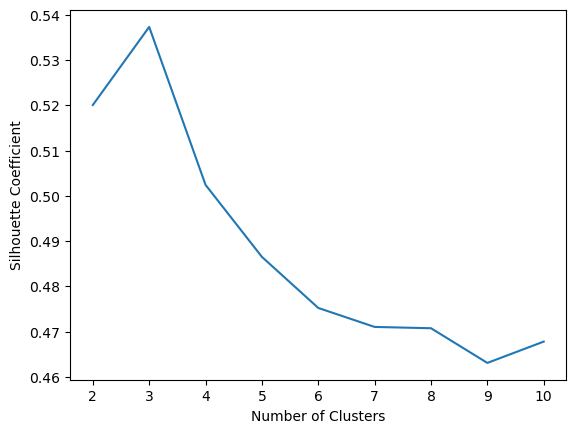

In [146]:
# plotting silhouette score
plt.plot(range(2,11), silhouette_coeff)
plt.xticks(range(2,11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.show()